In [1]:
%pip install datasets diffusers torch accelerate torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 13.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 14.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from accelerate.utils import write_basic_config

write_basic_config()

Configuration already exists at /home/elliottgruzin/.cache/huggingface/accelerate/default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.


/home/elliottgruzin/tutorials/diffusing/venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


False

In [3]:
import torch
# import torch_xla
# import torch_xla.core.xla_model as xm


if torch.cuda.is_available():
  print("Using CUDA")
  device = "cuda"
# elif xm.xla_device():
#   print("Using XLA")
#   device = xm.xla_device()
else:
  print('Using CPU')
  device = "cpu"

Using CUDA


In [12]:
from datasets import load_dataset

dataset = load_dataset("jiovine/pixel-art-nouns-2k")["train"]

Let's take a look at the dataset

In [13]:
dataset[0]['text']

'a character with square black glasses, a hotdog-shaped head and a peachy-colored body on a warm background'

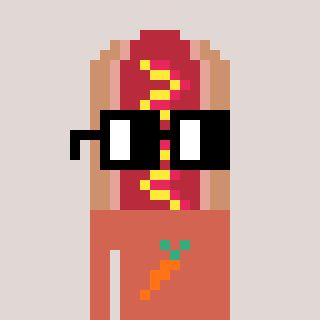

In [14]:
dataset[0]['image']

What does this look like numerically?

In [15]:
import numpy as np

np.array(dataset[0]['image'].convert('RGB'))

array([[[225, 215, 213],
        [225, 215, 213],
        [225, 215, 213],
        ...,
        [225, 215, 213],
        [225, 215, 213],
        [225, 215, 213]],

       [[225, 215, 213],
        [225, 215, 213],
        [225, 215, 213],
        ...,
        [225, 215, 213],
        [225, 215, 213],
        [225, 215, 213]],

       [[225, 215, 213],
        [225, 215, 213],
        [225, 215, 213],
        ...,
        [225, 215, 213],
        [225, 215, 213],
        [225, 215, 213]],

       ...,

       [[225, 215, 213],
        [225, 215, 213],
        [225, 215, 213],
        ...,
        [225, 215, 213],
        [225, 215, 213],
        [225, 215, 213]],

       [[225, 215, 213],
        [225, 215, 213],
        [225, 215, 213],
        ...,
        [225, 215, 213],
        [225, 215, 213],
        [225, 215, 213]],

       [[225, 215, 213],
        [225, 215, 213],
        [225, 215, 213],
        ...,
        [225, 215, 213],
        [225, 215, 213],
        [225, 215, 213]]

Each pixel is represented from 0-255 in RGB. We need to transform this to between -1 and 1 to train on.

In [16]:
from torchvision import transforms
import re

image_preprocessor = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
]
)

def text_preprocessor(text):
    match = re.search('(\w+-colored body on a \w+ background)', text)
    return match.group()

def preprocess(ds):
    images = [image_preprocessor(example.convert('RGB')) for example in ds['image']]
    text = [text_preprocessor(example) for example in ds['text']]
    return {"images": images, 'text': text, "original_text": ds["text"]}

dataset.set_transform(preprocess)

In [17]:
import torch

train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

In [18]:
next(iter(train_dataloader))['images'].shape

torch.Size([32, 3, 128, 128])

In [19]:
next(iter(train_dataloader))

{'images': tensor([[[[0.6706, 0.6706, 0.6706,  ..., 0.6706, 0.6706, 0.6706],
           [0.6706, 0.6706, 0.6706,  ..., 0.6706, 0.6706, 0.6706],
           [0.6706, 0.6706, 0.6706,  ..., 0.6706, 0.6706, 0.6706],
           ...,
           [0.6706, 0.6706, 0.6706,  ..., 0.6706, 0.6706, 0.6706],
           [0.6706, 0.6706, 0.6706,  ..., 0.6706, 0.6706, 0.6706],
           [0.6706, 0.6706, 0.6706,  ..., 0.6706, 0.6706, 0.6706]],
 
          [[0.6941, 0.6941, 0.6941,  ..., 0.6941, 0.6941, 0.6941],
           [0.6941, 0.6941, 0.6941,  ..., 0.6941, 0.6941, 0.6941],
           [0.6941, 0.6941, 0.6941,  ..., 0.6941, 0.6941, 0.6941],
           ...,
           [0.6941, 0.6941, 0.6941,  ..., 0.6941, 0.6941, 0.6941],
           [0.6941, 0.6941, 0.6941,  ..., 0.6941, 0.6941, 0.6941],
           [0.6941, 0.6941, 0.6941,  ..., 0.6941, 0.6941, 0.6941]],
 
          [[0.7647, 0.7647, 0.7647,  ..., 0.7647, 0.7647, 0.7647],
           [0.7647, 0.7647, 0.7647,  ..., 0.7647, 0.7647, 0.7647],
           [0.

In [12]:
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler

num_train_timesteps = 1000
num_inference_steps = 40

denoiser = UNet2DModel(
    sample_size=128,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    down_block_types=[
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D"
    ],
    up_block_types=[
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
    ],
    block_out_channels=(64, 128, 128, 128),
)

# scheduler = DDIMScheduler(beta_schedule='squaredcos_cap_v2')
# scheduler.num_inference_steps = 40
scheduler = DDPMScheduler(beta_schedule='scaled_linear')

In [13]:
from torch.optim import AdamW
from torch.nn import MSELoss

criterion = MSELoss()

optimizer = AdamW(denoiser.parameters(), lr=1e-4)
optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.01
)

In [9]:
import torchvision
from PIL import Image

def create_image_grid(images):
    images = (images / 2 + 0.5).clamp(0, 1)
    grid = torchvision.utils.make_grid(images, nrow=2)
    grid = grid.detach().cpu().permute(1, 2, 0).numpy() * 255
    grid_im = Image.fromarray(np.array(grid).astype(np.uint8))
    return grid_im

def save_image(images, path):
    grid = create_image_grid(images)
    grid.save(path)

['a character with square black sunglasses, a tooth-shaped head and a grayscale-colored body on a warm background', 'a character with square pink glasses, a goat-shaped head and a gunk-colored body on a cool background', 'a character with square glasses with black frames and red eyes, a cherry-shaped head and a peachy-colored body on a warm background', 'a character with square yellow and orange glasses, a mirror-shaped head and a bege-colored body on a warm background']
['grayscale-colored body on a warm background', 'gunk-colored body on a cool background', 'peachy-colored body on a warm background', 'bege-colored body on a warm background']


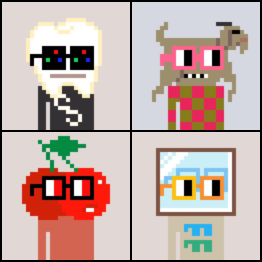

In [21]:
test = next(iter(train_dataloader))
test_images = test['images'][:4]
test_text = test['text'][:4]
print(test['original_text'][:4])
# save_image(test, 'test.png')
print(test_text)
create_image_grid(test_images)


In [16]:
def inference(noise, model, scheduler):
    model.eval()

    current_noise = torch.clone(noise)

    with torch.no_grad():
        for step in scheduler.timesteps:
            noise_pred = model(current_noise, step).sample
            current_noise = scheduler.step(noise_pred, step, current_noise).prev_sample

    generated_images = current_noise
    return generated_images

In [17]:
import matplotlib.pyplot as plt

def save_losses(losses, path):
    plt.plot(losses)
    plt.savefig(path)

In [18]:
# from tqdm import tqdm

# import accelerate

# accelerator = accelerate.Accelerator(mixed_precision='fp16')
# # accelerator = accelerate.Accelerator(mixed_precision='bf16')
# denoiser, optimizer, train_dataloader, scheduler = accelerator.prepare(denoiser, optimizer, train_dataloader, scheduler)


# def training_loop(model, optimizer, train_dataloader, scheduler, num_epochs):

#     model.train()

#     eval_set = torch.randn(4, 3, 128, 128).to(device)

#     for epoch in range(num_epochs):

#       losses = []
#       model.train()
#       for batch in tqdm(train_dataloader):
#           images = batch['images']
#           noise = torch.randn(images.shape, device=device)
#           bs = images.shape[0]

#           timesteps = torch.randint(0, num_train_timesteps - 1, (bs,), device=device, dtype=torch.long)
#           noisy_images = scheduler.add_noise(images, noise, timesteps)

#           predicted_noise = model(noisy_images, timesteps).sample

#           loss = criterion(predicted_noise, noise)
#           accelerator.backward(loss)
#           optimizer.step()
#           optimizer.zero_grad()

#           losses.append(loss.item())

#       loss = np.mean(losses)
#       model.eval()
#       generated_images = inference(eval_set, model, scheduler)
#       save_image(generated_images, f'epoch_{epoch}.png')
#       save_losses(losses, f'losses_{epoch}.png')
#       print(f'Epoch {epoch} loss: {loss.item()}')




In [19]:
# training_loop(denoiser, optimizer, train_dataloader, scheduler, 20)

In [20]:
# create_image_grid(inference(torch.randn(4, 3, 128, 128).to(device), denoiser, scheduler))

In [21]:
# torch.cuda.empty_cache()

Create a text-based conditional model

In [23]:
from transformers import CLIPTextModel, CLIPTokenizerFast

encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14")
tokenizer = CLIPTokenizerFast.from_pretrained("openai/clip-vit-large-patch14")

In [24]:
text = "This is a test sentence"

tokenized = tokenizer(text, padding='max_length', max_length=tokenizer.model_max_length, return_tensors='pt')

In [25]:
encoded = encoder(**tokenized).last_hidden_state
encoded.shape

torch.Size([1, 77, 768])

In [26]:
from diffusers import UNet2DConditionModel

text_to_image_denoiser = UNet2DConditionModel(
    sample_size=128,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    down_block_types=[
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D"
    ],
    up_block_types=[
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
    ],
    block_out_channels=(64, 128, 128, 128),
    cross_attention_dim=encoded.shape[-1]
)

scheduler = DDPMScheduler(beta_schedule='scaled_linear')

In [27]:
def collate_fn(examples):
    tokenized = tokenizer(
        [example['text'] for example in examples],
        padding='max_length', max_length=tokenizer.model_max_length, return_tensors='pt'
        ).input_ids
    images = torch.stack([example['images'] for example in examples])
    images = images.to(memory_format=torch.contiguous_format).float()
    return {"images": images, 'text': tokenized}

train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)


In [34]:
from tqdm import tqdm

def conditional_inference(noise, model, scheduler, encoded_text):
    model.eval()

    current_noise = torch.clone(noise)

    with torch.no_grad():
        for step in tqdm(scheduler.timesteps):
            noise_pred = model(current_noise, step, encoded_text).sample
            current_noise = scheduler.step(noise_pred, step, current_noise).prev_sample

    generated_images = current_noise
    return generated_images

In [35]:
import accelerate

optimizer = AdamW(text_to_image_denoiser.parameters(), lr=1e-4)
accelerator = accelerate.Accelerator(mixed_precision='fp16')
text_to_image_denoiser, optimizer, train_dataloader, scheduler, tokenizer, encoder = accelerator.prepare(text_to_image_denoiser, optimizer, train_dataloader, scheduler, tokenizer, encoder)

def conditional_generation_training_loop(model, optimizer, train_dataloader, scheduler, num_epochs, encoder):

    inference_text = [
        'a character with round green glasses, a bull-shaped head and a red-colored body on a cool background',
        'a character with no glasses, a robot-shaped head and a teal-colored body on a warm background',
        'a character with square pink and red glasses, a head with afro hair and a hotbrown-colored body on a warm background',
        'a character with round pink sunglasses, a toaster-shaped head and a redpinkish-colored body on a grey background',
    ]

    inference_tokenized_text = tokenizer(inference_text, padding='max_length', max_length=tokenizer.model_max_length, return_tensors='pt').to(device)
    inference_encoded_text = encoder(**inference_tokenized_text).last_hidden_state

    model.train()
    encoder.requires_grad_(False)

    eval_set = torch.randn(4, 3, 128, 128).to(device)

    for epoch in range(num_epochs):

      losses = []
      model.train()
      for batch in tqdm(train_dataloader):
          images = batch['images']
          token_ids = batch['text']
          encoded = encoder(token_ids).last_hidden_state
          noise = torch.randn(images.shape, device=device)
          bs = images.shape[0]

          timesteps = torch.randint(0, num_train_timesteps - 1, (bs,), device=device, dtype=torch.long)
          noisy_images = scheduler.add_noise(images, noise, timesteps)

          predicted_noise = model(noisy_images, timesteps, encoded).sample

          loss = criterion(predicted_noise, noise)
          accelerator.backward(loss)
          optimizer.step()
          optimizer.zero_grad()

          losses.append(loss.item())

      loss = np.mean(losses)
      model.eval()
      generated_images = conditional_inference(eval_set, model, scheduler, inference_encoded_text)
      save_image(generated_images, f'epoch_{epoch}.png')
      save_losses(losses, f'losses_{epoch}.png')
      print(f'Epoch {epoch} loss: {loss.item()}')




100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:15<00:00,  5.13it/s]


Epoch 0 loss: 0.026836336959922123


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:46<00:00,  6.01it/s]


Epoch 1 loss: 0.020650070352805038


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:57<00:00,  3.37it/s]


...

Epoch 32 loss: 0.008122904107920707


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:03<00:00,  8.09it/s]


Epoch 33 loss: 0.008092389401373646


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:21<00:00,  7.07it/s]


Epoch 34 loss: 0.00723417020506329


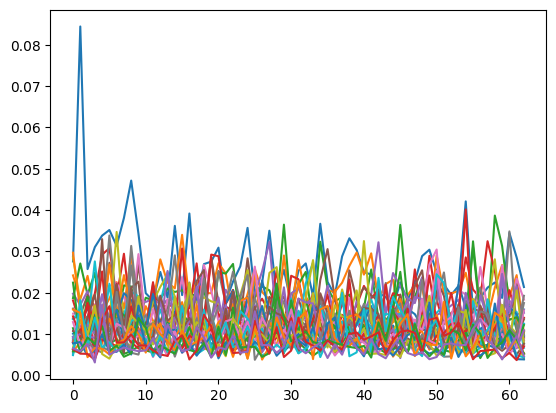

In [36]:
conditional_generation_training_loop(text_to_image_denoiser, optimizer, train_dataloader, scheduler, 35, encoder)

In [37]:
text_to_image_denoiser.save_pretrained('model_2')